# Importing Dependencies

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow import keras
from PIL import Image 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

# Downloading .jpg files

In [2]:
mask_files = os.listdir(r'C:\Users\Ashok\DMML2\archive (4)\data\with_mask')
not_mask_files = os.listdir(r'C:\Users\Ashok\DMML2\archive (4)\data\without_mask')

In [3]:
type(mask_files)

list

In [4]:
type(not_mask_files)

list

In [5]:
print(mask_files[:5])
print(not_mask_files[:5])

['with_mask_1.jpg', 'with_mask_10.jpg', 'with_mask_100.jpg', 'with_mask_1000.jpg', 'with_mask_1001.jpg']
['without_mask_1.jpg', 'without_mask_10.jpg', 'without_mask_100.jpg', 'without_mask_1000.jpg', 'without_mask_1001.jpg']


In [6]:
print(len(mask_files))
print(len(not_mask_files))

3725
3828


## Making List variables as image labels

In [7]:
mask_labels = [1]*3725
not_mask_labels = [0]*3828
dataset_labels = mask_labels+not_mask_labels

## Image Displaying

In [8]:
def image_show(s):
   img = mpimg.imread(s)
   plt.imshow(img)
   plt.show()

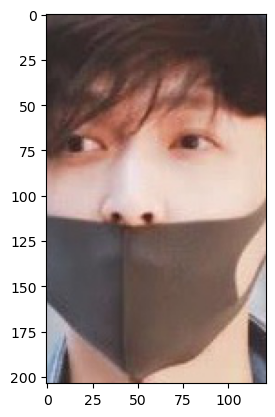

In [9]:
image_show(r'C:\Users\Ashok\DMML2\archive (4)\data\with_mask\with_mask_1001.jpg')

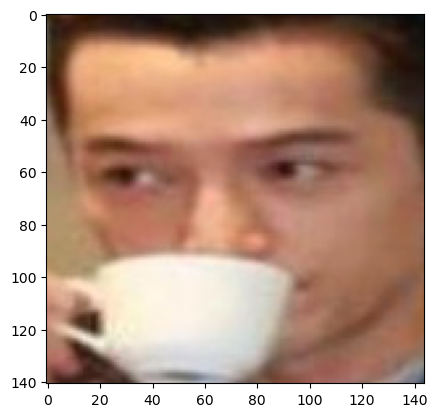

In [10]:
image_show(r'C:\Users\Ashok\DMML2\archive (4)\data\without_mask/without_mask_1002.jpg')

# Image Pre-Processing

## Resizing, Converting and making a dataset

In [11]:
dataset = []

for img_file in mask_files:

  image = Image.open(r'C:/Users/Ashok/DMML2/archive (4)/data/with_mask/' + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  dataset.append(image)

for img_file in not_mask_files:

  image = Image.open(r'C:/Users/Ashok/DMML2/archive (4)/data/without_mask/' + img_file)
  image = image.resize((128,128))
  image = image.convert('RGB')
  image = np.array(image)
  dataset.append(image)

C:\Users\Ashok\anaconda3\Lib\site-packages\PIL\Image.py:970: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [12]:
type(dataset)

list

In [13]:
dataset[10]

array([[[170, 164, 166],
        [177, 171, 173],
        [179, 173, 175],
        ...,
        [154, 152, 157],
        [169, 167, 172],
        [178, 176, 181]],

       [[179, 173, 175],
        [183, 177, 179],
        [185, 179, 181],
        ...,
        [132, 130, 134],
        [123, 121, 125],
        [127, 125, 129]],

       [[188, 180, 183],
        [191, 183, 186],
        [182, 175, 177],
        ...,
        [213, 211, 214],
        [184, 182, 185],
        [158, 156, 159]],

       ...,

       [[ 18,  16,  17],
        [ 18,  16,  17],
        [ 18,  16,  17],
        ...,
        [ 71,  48,  48],
        [ 84,  61,  63],
        [117,  94,  97]],

       [[ 18,  16,  17],
        [ 18,  16,  17],
        [ 18,  16,  17],
        ...,
        [ 76,  52,  50],
        [ 96,  72,  71],
        [131, 107, 108]],

       [[ 18,  16,  17],
        [ 18,  16,  17],
        [ 18,  16,  17],
        ...,
        [ 85,  60,  57],
        [ 99,  73,  73],
        [128, 104, 104]]

In [14]:
print(len(dataset))
print(dataset[0].shape)

7553
(128, 128, 3)


## Converting in numpy arrays

In [15]:
X = np.array(dataset)
Y = np.array(dataset_labels)

In [16]:
print(X.shape)
print(Y.shape)

(7553, 128, 128, 3)
(7553,)


# Using Train Test Split

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=100)

# Scaling

In [18]:
X_train = X_train/255
X_test = X_test/255
print(X_train.shape)
print(X_test.shape)

(6042, 128, 128, 3)
(1511, 128, 128, 3)


# Building CNN Model

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def create_cnn_model(input_shape=(128, 128, 3), num_classes=2):
    model = Sequential([
        Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2,2)),
        Conv2D(64, kernel_size=(3,3), activation='relu'),
        MaxPooling2D(pool_size=(2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='sigmoid')
    ])
    return model

# Compile the model
model = create_cnn_model()
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, Y_train, validation_split=0.3, epochs=10)

Epoch 1/10
133/133 [==============================] - 60s 424ms/step - loss: 0.5592 - accuracy: 0.7654 - val_loss: 0.3123 - val_accuracy: 0.8605
Epoch 2/10
133/133 [==============================] - 46s 346ms/step - loss: 0.2997 - accuracy: 0.8803 - val_loss: 0.2381 - val_accuracy: 0.9073
Epoch 3/10
133/133 [==============================] - 47s 353ms/step - loss: 0.2457 - accuracy: 0.9054 - val_loss: 0.2211 - val_accuracy: 0.9046
Epoch 4/10
133/133 [==============================] - 48s 364ms/step - loss: 0.2016 - accuracy: 0.9208 - val_loss: 0.2401 - val_accuracy: 0.9145
Epoch 5/10
133/133 [==============================] - 49s 369ms/step - loss: 0.1716 - accuracy: 0.9385 - val_loss: 0.2167 - val_accuracy: 0.9266
Epoch 6/10
133/133 [==============================] - 48s 362ms/step - loss: 0.1504 - accuracy: 0.9440 - val_loss: 0.2761 - val_accuracy: 0.9101
Epoch 7/10
133/133 [==============================] - 49s 366ms/step - loss: 0.1373 - accuracy: 0.9444 - val_loss: 0.2533 - val_ac

# Evaluating Model Using Test data

In [35]:
loss, accuracy = model.evaluate(X_test,Y_test)

48/48 [==============================] - 4s 75ms/step - loss: 0.2549 - accuracy: 0.9325


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


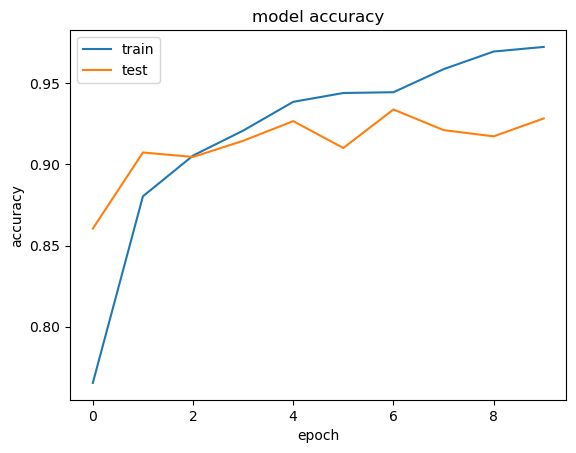

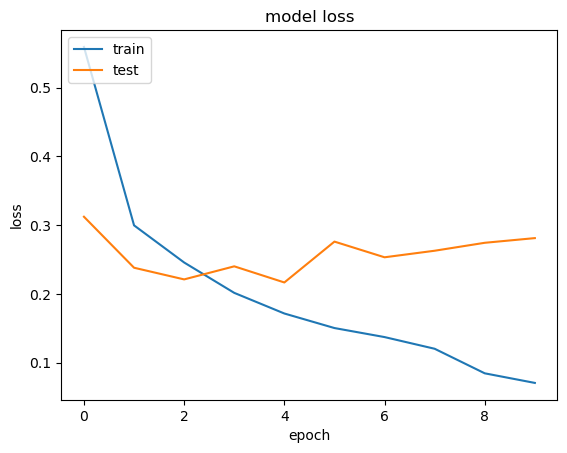

In [36]:
print(history.history.keys())
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [24]:
#Classification Report
from sklearn.metrics import classification_report
 
y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)
 
print(classification_report(Y_test, y_pred))

48/48 [==============================] - 5s 84ms/step
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       783
           1       0.90      0.94      0.92       728

    accuracy                           0.92      1511
   macro avg       0.92      0.92      0.92      1511
weighted avg       0.92      0.92      0.92      1511



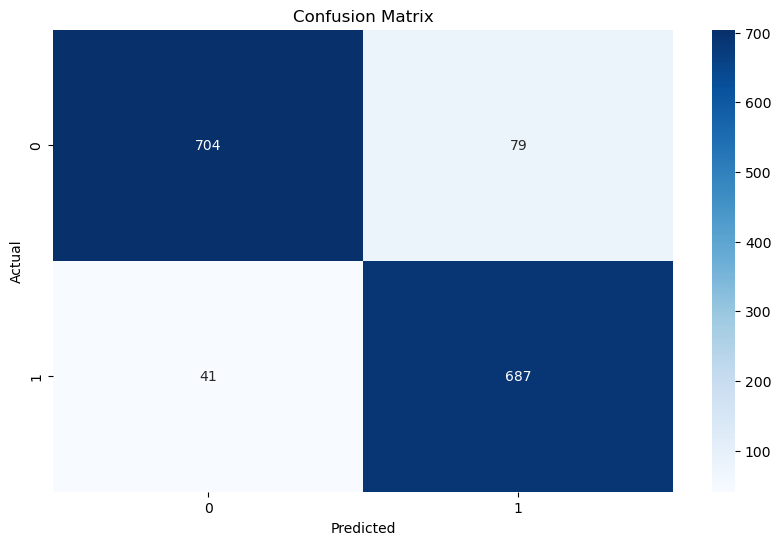

In [27]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)
#plot confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()